In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import Axes

%matplotlib inline 

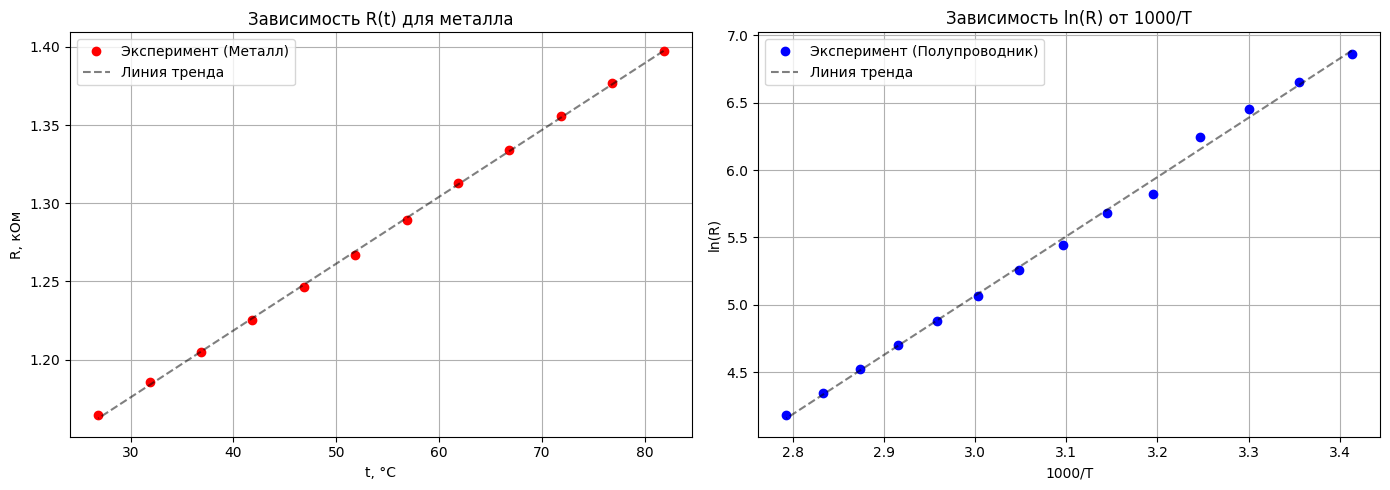

In [ ]:
T_met = np.array([355, 350, 345, 340, 335, 330, 325, 320, 315, 310, 305, 300])
t_celsius = T_met - 273.15
R_met = np.array([1.3976, 1.3767, 1.3557, 1.3344, 1.3127, 1.2896, 1.2671, 1.2462, 1.2251, 1.2046, 1.1855, 1.1645])

T_semi = np.array([293, 298, 303, 308, 313, 318, 323, 328, 333, 338, 343, 348, 353, 358])
inv_T = 1000 / T_semi
ln_R = np.array([6.863, 6.650, 6.454, 6.247, 5.822, 5.684, 5.447, 5.256, 5.063, 4.882, 4.704, 4.522, 4.348, 4.184])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1: Axes = ax1
ax2: Axes = ax2

ax1.plot(t_celsius, R_met, 'ro', label='Эксперимент (Металл)')
z1 = np.polyfit(t_celsius, R_met, 1) # Линия тренда
p1 = np.poly1d(z1)
ax1.plot(t_celsius, p1(t_celsius), "k--", alpha=0.5, label='Линия тренда')
ax1.set_title('Зависимость R(t) для металла')
ax1.set_xlabel('t, °C')
ax1.set_ylabel('R, кОм')
ax1.grid(True)
ax1.legend()

ax2.plot(inv_T, ln_R, 'bo', label='Эксперимент (Полупроводник)')
z2 = np.polyfit(inv_T, ln_R, 1) # Линия тренда
p2 = np.poly1d(z2)
ax2.plot(inv_T, p2(inv_T), "k--", alpha=0.5, label='Линия тренда')
ax2.set_title('Зависимость ln(R) от 1000/T')
ax2.set_xlabel('1000/T, 1/K')
ax2.set_ylabel('ln(R)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_190308/3665129288.py:52: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_xlabel('$t, ^\circ C$', fontsize=11)
/tmp/ipykernel_190308/3665129288.py:71: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_ylabel('$\ln(R)$', fontsize=11)


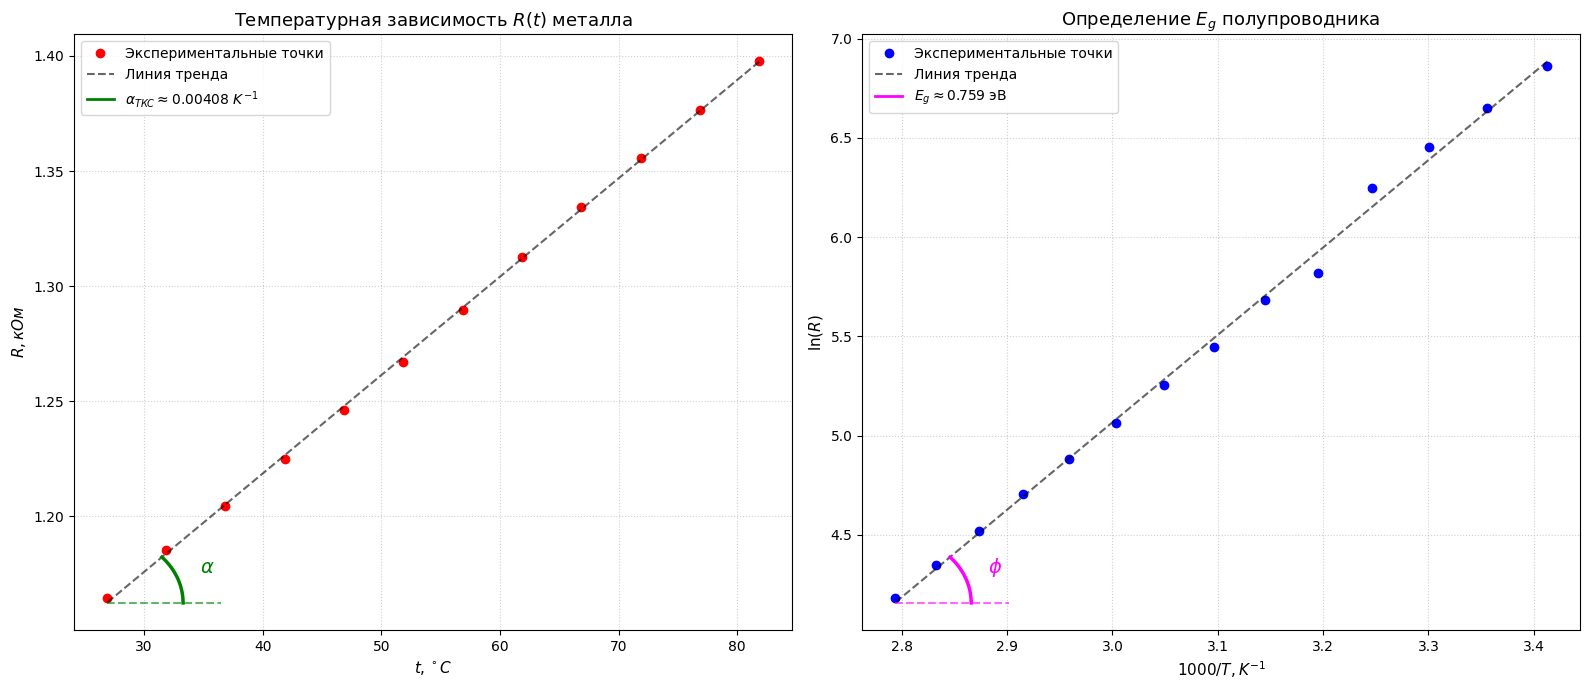

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Данные
T_met = np.array([355, 350, 345, 340, 335, 330, 325, 320, 315, 310, 305, 300])
t_celsius = T_met - 273.15
R_met = np.array([1.3976, 1.3767, 1.3557, 1.3344, 1.3127, 1.2896, 1.2671, 1.2462, 1.2251, 1.2046, 1.1855, 1.1645])

T_semi = np.array([293, 298, 303, 308, 313, 318, 323, 328, 333, 338, 343, 348, 353, 358])
inv_T = 1000 / T_semi
ln_R = np.array([6.863, 6.650, 6.454, 6.247, 5.822, 5.684, 5.447, 5.256, 5.063, 4.882, 4.704, 4.522, 4.348, 4.184])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

def draw_angle_perfect(ax, x0, y0, slope, color, label, radius_px=60):
    fig.canvas.draw()
    p0_px = ax.transData.transform(np.array([[x0, y0]]))[0]
    p1_px = ax.transData.transform(np.array([[x0 + 1, y0 + slope]]))[0]
    
    dx_px, dy_px = p1_px - p0_px
    visual_angle = np.arctan2(dy_px, dx_px)
    
    theta = np.linspace(0, visual_angle, 50)
    arc_px = np.column_stack([p0_px[0] + radius_px * np.cos(theta), p0_px[1] + radius_px * np.sin(theta)])
    arc_data = ax.transData.inverted().transform(arc_px)
    ax.plot(arc_data[:, 0], arc_data[:, 1], color=color, lw=2.5)
    
    horiz_px = np.array([[p0_px[0] + radius_px * 1.5, p0_px[1]]])
    horiz_data = ax.transData.inverted().transform(horiz_px)[0]
    ax.plot([x0, horiz_data[0]], [y0, horiz_data[1]], color=color, ls='--', lw=1.5, alpha=0.6)
    
    text_theta = visual_angle / 2
    text_px = ax.transData.inverted().transform(np.array([[p0_px[0] + (radius_px + 25) * np.cos(text_theta), 
                                                           p0_px[1] + (radius_px + 25) * np.sin(text_theta)]]))[0]
    ax.text(text_px[0], text_px[1], label, color=color, fontsize=14, fontweight='bold', va='center', ha='center')

# --- График 1: Металл ---
z1 = np.polyfit(t_celsius, R_met, 1)
p1 = np.poly1d(z1)
R0 = p1(0)
alpha_tks = z1[0] / R0

line_exp1 = ax1.plot(t_celsius, R_met, 'ro', label='Экспериментальные точки')
line_trend1 = ax1.plot(t_celsius, p1(t_celsius), "k--", alpha=0.6, label='Линия тренда')

# Прокси-элемент для легенды (зеленая дуга)
angle_patch1 = mlines.Line2D([], [], color='green', marker=None, lw=2, label=f'$\\alpha_{{ТКС}} \\approx {alpha_tks:.5f}$ $K^{{-1}}$')

draw_angle_perfect(ax1, np.min(t_celsius), p1(np.min(t_celsius)), z1[0], 'green', r'$\alpha$')
ax1.set_title('Температурная зависимость $R(t)$ металла', fontsize=13)
ax1.set_xlabel('$t, ^\circ C$', fontsize=11)
ax1.set_ylabel('$R, кОм$', fontsize=11)
ax1.legend(handles=[line_exp1[0], line_trend1[0], angle_patch1], loc='best', fontsize=10)

# --- График 2: Полупроводник ---
z2 = np.polyfit(inv_T, ln_R, 1)
p2 = np.poly1d(z2)
k_ev = 8.617e-5 
Eg = 2 * k_ev * z2[0] * 1000 

line_exp2 = ax2.plot(inv_T, ln_R, 'bo', label='Экспериментальные точки')
line_trend2 = ax2.plot(inv_T, p2(inv_T), "k--", alpha=0.6, label='Линия тренда')

# Прокси-элемент для легенды (пурпурная дуга)
angle_patch2 = mlines.Line2D([], [], color='magenta', marker=None, lw=2, label=f'$E_g \\approx {abs(Eg):.3f}$ эВ')

draw_angle_perfect(ax2, np.min(inv_T), p2(np.min(inv_T)), z2[0], 'magenta', r'$\phi$')
ax2.set_title('Определение $E_g$ полупроводника', fontsize=13)
ax2.set_xlabel('$1000/T, K^{-1}$', fontsize=11)
ax2.set_ylabel('$\ln(R)$', fontsize=11)
ax2.legend(handles=[line_exp2[0], line_trend2[0], angle_patch2], loc='best', fontsize=10)

for ax in [ax1, ax2]:
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

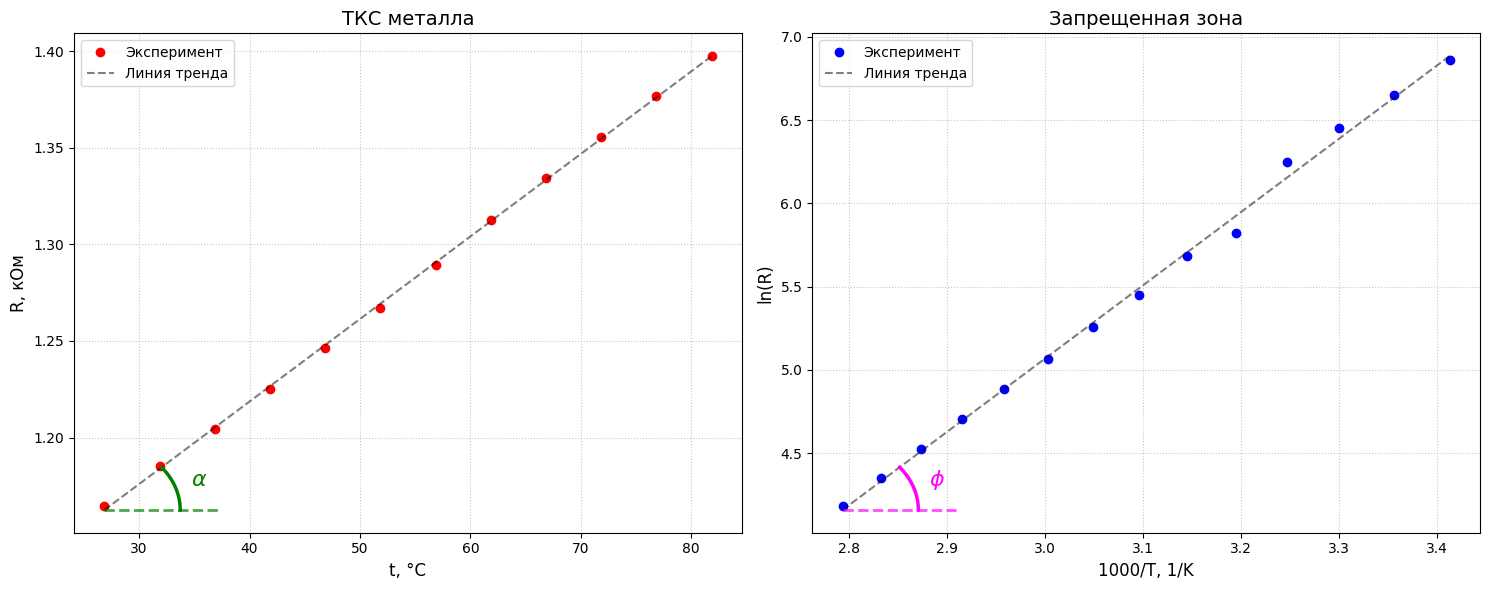

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Ваши данные
T_met = np.array([355, 350, 345, 340, 335, 330, 325, 320, 315, 310, 305, 300])
t_celsius = T_met - 273.15
R_met = np.array([1.3976, 1.3767, 1.3557, 1.3344, 1.3127, 1.2896, 1.2671, 1.2462, 1.2251, 1.2046, 1.1855, 1.1645])

T_semi = np.array([293, 298, 303, 308, 313, 318, 323, 328, 333, 338, 343, 348, 353, 358])
inv_T = 1000 / T_semi
ln_R = np.array([6.863, 6.650, 6.454, 6.247, 5.822, 5.684, 5.447, 5.256, 5.063, 4.882, 4.704, 4.522, 4.348, 4.184])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- НОВАЯ "ЖЕЛЕЗОБЕТОННАЯ" ФУНКЦИЯ ---
def draw_angle_perfect(ax, x0, y0, slope, color, label, radius_px=60):
    # Обязательно обновляем холст, чтобы получить точные пиксели экрана
    fig.canvas.draw()
    
    # 1. Получаем стартовую точку (x0, y0) в ПИКСЕЛЯХ экрана
    p0_data = np.array([[x0, y0]])
    p0_px = ax.transData.transform(p0_data)[0]
    
    # 2. Берем контрольную точку на линии тренда, чтобы узнать ее визуальный наклон
    x1 = x0 + 1 
    y1 = y0 + slope * 1
    p1_data = np.array([[x1, y1]])
    p1_px = ax.transData.transform(p1_data)[0]
    
    # 3. Считаем реальный угол линии тренда НА МОНИТОРЕ
    dx_px = p1_px[0] - p0_px[0]
    dy_px = p1_px[1] - p0_px[1]
    visual_angle = np.arctan2(dy_px, dx_px)
    
    # 4. Генерируем точки идеальной дуги в пикселях 
    theta = np.linspace(0, visual_angle, 50)
    arc_x_px = p0_px[0] + radius_px * np.cos(theta)
    arc_y_px = p0_px[1] + radius_px * np.sin(theta)
    
    # 5. Возвращаем пиксели обратно в систему координат графика и рисуем линию
    arc_px = np.column_stack([arc_x_px, arc_y_px])
    arc_data = ax.transData.inverted().transform(arc_px)
    ax.plot(arc_data[:, 0], arc_data[:, 1], color=color, lw=2.5)
    
    # 6. Рисуем пунктирную горизонтальную линию (откуда отсчитываем угол)
    horiz_x_px = p0_px[0] + radius_px * 1.5
    horiz_y_px = p0_px[1]
    horiz_px = np.array([[horiz_x_px, horiz_y_px]])
    horiz_data = ax.transData.inverted().transform(horiz_px)[0]
    ax.plot([x0, horiz_data[0]], [y0, horiz_data[1]], color=color, ls='--', lw=2, alpha=0.7)
    
    # 7. Ставим подпись точно по центру угла
    text_theta = visual_angle / 2
    text_x_px = p0_px[0] + (radius_px + 20) * np.cos(text_theta)
    text_y_px = p0_px[1] + (radius_px + 20) * np.sin(text_theta)
    text_px = np.array([[text_x_px, text_y_px]])
    text_data = ax.transData.inverted().transform(text_px)[0]
    
    ax.text(text_data[0], text_data[1], label, color=color, 
            fontsize=16, fontweight='bold', va='center', ha='center')


# --- График 1: Металл ---
ax1.plot(t_celsius, R_met, 'ro', label='Эксперимент')
z1 = np.polyfit(t_celsius, R_met, 1)
p1 = np.poly1d(z1)
ax1.plot(t_celsius, p1(t_celsius), "k--", alpha=0.5, label='Линия тренда')

# Ставим угол в самую нижнюю левую точку тренда
x_start_met = np.min(t_celsius)
draw_angle_perfect(ax1, x_start_met, p1(x_start_met), z1[0], 'green', r'$\alpha$')

ax1.set_title('ТКС металла', fontsize=14)
ax1.set_xlabel('t, °C', fontsize=12)
ax1.set_ylabel('R, кОм', fontsize=12)

# --- График 2: Полупроводник ---
ax2.plot(inv_T, ln_R, 'bo', label='Эксперимент')
z2 = np.polyfit(inv_T, ln_R, 1)
p2 = np.poly1d(z2)
ax2.plot(inv_T, p2(inv_T), "k--", alpha=0.5, label='Линия тренда')

# Ставим угол в самую нижнюю левую точку тренда
x_start_semi = np.min(inv_T)
draw_angle_perfect(ax2, x_start_semi, p2(x_start_semi), z2[0], 'magenta', r'$\phi$')

ax2.set_title('Запрещенная зона', fontsize=14)
ax2.set_xlabel('1000/T, 1/K', fontsize=12)
ax2.set_ylabel('ln(R)', fontsize=12)

for ax in [ax1, ax2]:
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()